# 01. Data sources and cohort construction

This notebook assembles the development and external evaluation cohorts from seven public releases, applies the eligibility criteria and records attrition at each step. It produces the cohort files used by `02_model_development.ipynb` and `03_evaluation.ipynb`.

**Environment.** Kaggle notebook with internet access. The seven datasets listed in the README must be attached as inputs. Run time is about 20 minutes, most of it the download of the ISIC Archive metadata.

**Outputs** (written to `outputs/`)

| File | Content |
|---|---|
| `cohort_arm_a_endpoint.csv` | Histopathology-confirmed cohort (primary analysis) |
| `cohort_arm_b_endpoint.csv` | All confirmation methods (used for Fitzpatrick17k) |
| `attrition_arm_a_endpoint.csv` | Images removed at each eligibility step |
| `cohort_summary.json` | Counts used in Figure 1 |
| `table1_cohort_summary.csv` | Basis of Table 1 |
| `malignant_counts_by_skin_tone.csv` | Biopsy-confirmed malignant lesions by skin tone in the external data |
| other `.csv` | Provenance, release overlap, verification and precision tables |

## 1. Setup

In [1]:
import json
import os
import subprocess
import sys
import urllib.request
import warnings
import zipfile
from pathlib import Path

import pandas as pd


def find_repo():
    # The repository root is the folder that contains src/dermcal. On Kaggle it
    # is usually attached as a dataset under /kaggle/input.
    candidates = [Path.cwd(), *Path.cwd().parents]
    kaggle = Path("/kaggle/input")
    if kaggle.exists():
        for depth in ("*", "*/*", "*/*/*", "*/*/*/*"):   # uploaded zips add a folder level
            candidates += sorted(kaggle.glob(depth))
    for p in candidates:
        if (p / "src" / "dermcal").is_dir():
            return p
    raise FileNotFoundError("Repository not found: attach it as a Kaggle dataset or run from inside it.")


REPO = find_repo()
sys.path.insert(0, str(REPO / "src"))

from dermcal import (Config, discover, load_all, coalesce_across_releases,
                     enrich_confirmation_from_archive, dedup, cohort, power, plots)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

DATA_ROOT = Path("/kaggle/input")
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("cache"); CACHE_DIR.mkdir(exist_ok=True)
OFFICIAL = Path("isic_official"); OFFICIAL.mkdir(exist_ok=True)
ARCHIVE_SLIM = Path("isic_archive_metadata.csv")
AKIEC_IS_MALIGNANT = False     # actinic keratosis counted as benign (premalignant)

plots.set_style()
print("repository:", REPO)

repository: /kaggle/input/datasets/immuhammadsumairrazi/skin-tone-calibration/skin-tone-calibration


In [2]:
# Kaggle datasets used in the reported run. Stop early if any is not attached.
REQUIRED_INPUTS = {
    "ISIC 2017":      "johnchfr/isic-2017",
    "ISIC 2018":      "nightfury007/ham10000-isic2018-raw",
    "ISIC 2019":      "salviohexia/isic-2019-skin-lesion-images-for-classification",
    "ISIC 2020":      "prashantjeswani/siimisic2020",
    "Fitzpatrick17k": "nazmusresan/fitzpatrick17k",
    "DDI":            "souvikda/ddidiversedermatologyimages-multimodal-dataset",
    "PAD-UFES-20":    "maxjen/pad-ufes-20",
}
mounted = set()
if DATA_ROOT.exists():
    for root, dirs, _ in os.walk(DATA_ROOT):
        mounted.update(dirs)
        if root.count(os.sep) - str(DATA_ROOT).count(os.sep) >= 2:
            dirs[:] = []
missing = {k: v for k, v in REQUIRED_INPUTS.items() if v.split("/")[1] not in mounted}
if missing:
    raise RuntimeError("Datasets not attached:\n" +
                       "\n".join(f"  {k:<15} {v}" for k, v in missing.items()))
print(f"all {len(REQUIRED_INPUTS)} datasets attached")

all 7 datasets attached


## 2. Official label files

The ISIC 2019 test ground truth and the ISIC 2018 lesion groupings are not in the Kaggle mirrors, so the official label files are downloaded from the ISIC challenge archive.

In [3]:
S3 = "https://isic-archive.s3.amazonaws.com/challenges"
LABEL_FILES = [
    ("ISIC-2017_Training_Part3_GroundTruth.csv",    f"{S3}/2017/ISIC-2017_Training_Part3_GroundTruth.csv",    False),
    ("ISIC-2017_Validation_Part3_GroundTruth.csv",  f"{S3}/2017/ISIC-2017_Validation_Part3_GroundTruth.csv",  False),
    ("ISIC-2017_Test_v2_Part3_GroundTruth.csv",     f"{S3}/2017/ISIC-2017_Test_v2_Part3_GroundTruth.csv",     False),
    ("ISIC2018_Task3_Training_GroundTruth.zip",     f"{S3}/2018/ISIC2018_Task3_Training_GroundTruth.zip",     True),
    ("ISIC2018_Task3_Test_GroundTruth.zip",         f"{S3}/2018/ISIC2018_Task3_Test_GroundTruth.zip",         True),
    ("ISIC2018_Task3_Training_LesionGroupings.csv", f"{S3}/2018/ISIC2018_Task3_Training_LesionGroupings.csv", False),
    ("ISIC_2019_Training_GroundTruth.csv",          f"{S3}/2019/ISIC_2019_Training_GroundTruth.csv",          False),
    ("ISIC_2019_Training_Metadata.csv",             f"{S3}/2019/ISIC_2019_Training_Metadata.csv",             False),
    ("ISIC_2019_Test_GroundTruth.csv",              f"{S3}/2019/ISIC_2019_Test_GroundTruth.csv",              False),
    ("ISIC_2019_Test_Metadata.csv",                 f"{S3}/2019/ISIC_2019_Test_Metadata.csv",                 False),
    ("ISIC_2020_Training_GroundTruth_v2.csv",       f"{S3}/2020/ISIC_2020_Training_GroundTruth_v2.csv",       False),
    ("ISIC_2020_Training_Duplicates.csv",           f"{S3}/2020/ISIC_2020_Training_Duplicates.csv",           False),
    ("ISIC_2020_Test_Metadata.csv",                 f"{S3}/2020/ISIC_2020_Test_Metadata.csv",                 False),
]

manifest = []
for name, url, is_zip in LABEL_FILES:
    dest = OFFICIAL / name
    try:
        if not dest.exists() or dest.stat().st_size == 0:
            urllib.request.urlretrieve(url, dest)
        if is_zip:
            with zipfile.ZipFile(dest) as z:
                z.extractall(OFFICIAL)
        manifest.append({"file": name, "bytes": dest.stat().st_size, "status": "ok"})
    except Exception as e:
        manifest.append({"file": name, "bytes": 0, "status": f"failed: {type(e).__name__}"})

for p in list(OFFICIAL.rglob("*.csv")):        # flatten folders created by the zip files
    if p.parent != OFFICIAL and not (OFFICIAL / p.name).exists():
        p.replace(OFFICIAL / p.name)

(OFFICIAL / "download_manifest.json").write_text(json.dumps(manifest, indent=2))
display(pd.DataFrame(manifest))

n19 = len(pd.read_csv(OFFICIAL / "ISIC_2019_Test_GroundTruth.csv"))
assert n19 == 8238, f"ISIC 2019 test ground truth has {n19:,} rows, expected 8,238"

,file,bytes,status
0,ISIC-2017_Training_Part3_GroundTruth.csv,44040,ok
1,ISIC-2017_Validation_Part3_GroundTruth.csv,3340,ok
2,ISIC-2017_Test_v2_Part3_GroundTruth.csv,13240,ok
3,ISIC2018_Task3_Training_GroundTruth.zip,36681,ok
4,ISIC2018_Task3_Test_GroundTruth.zip,12202,ok
5,ISIC2018_Task3_Training_LesionGroupings.csv,492996,ok
6,ISIC_2019_Training_GroundTruth.csv,1291479,ok
7,ISIC_2019_Training_Metadata.csv,1214351,ok
8,ISIC_2019_Test_GroundTruth.csv,464810,ok
9,ISIC_2019_Test_Metadata.csv,293638,ok


## 3. ISIC Archive metadata

The challenge ground-truth files do not say how each diagnosis was confirmed. The ISIC Archive records `diagnosis_confirm_type` for every image, so the full Archive metadata (about 553,000 records) is downloaded with `isic-cli` and reduced to identifier and confirmation type.

In [4]:
if not ARCHIVE_SLIM.exists():
    raw = Path("isic_archive_raw.csv")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "isic-cli"], check=True)
    subprocess.run(f"isic metadata download > {raw}", shell=True, check=True)
    arch = pd.read_csv(raw, low_memory=False)
    id_col = next(c for c in arch.columns if c.lower() in ("isic_id", "image_id", "name", "id"))
    conf_col = next(c for c in arch.columns if "confirm" in c.lower())
    (arch[[id_col, conf_col]]
        .rename(columns={id_col: "isic_id", conf_col: "diagnosis_confirm_type"})
        .dropna(subset=["isic_id"]).drop_duplicates("isic_id")
        .to_csv(ARCHIVE_SLIM, index=False))
    raw.unlink()

arch_slim = pd.read_csv(ARCHIVE_SLIM)
print(f"confirmation type available for {len(arch_slim):,} Archive images")
arch_slim["diagnosis_confirm_type"].value_counts(dropna=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.9 MB/s eta 0:00:00


If you have been granted special permissions, logging in with `isic user login` might return more data.



confirmation type available for 553,019 Archive images


diagnosis_confirm_type
NaN                                              406455
histopathology                                    50294
single contributor clinical assessment            33999
serial imaging showing no change                  31536
single image expert consensus                     29358
confocal microscopy with consensus dermoscopy      1377
Name: count, dtype: int64

## 4. Load, harmonise and de-duplicate

Each file is identified by its column headers rather than its name (`dermcal.config.SIGNATURES`), loaded into a common schema (`dermcal.schemas`), and fields that one release carries for an image are copied to the same image in the other releases. Development images are then de-duplicated on the ISIC identifier.

In [5]:
PATH_OVERRIDES = {
    "isic2019_test":             str(OFFICIAL / "ISIC_2019_Test_GroundTruth.csv"),
    "isic2019_test_meta":        str(OFFICIAL / "ISIC_2019_Test_Metadata.csv"),
    "isic2018_lesion_groupings": str(OFFICIAL / "ISIC2018_Task3_Training_LesionGroupings.csv"),
    # never loaded (no public ground truth); listed so that discovery does not search for it
    "isic2020_test":             str(OFFICIAL / "ISIC_2020_Test_Metadata.csv"),
}
cfg = Config(data_root=DATA_ROOT, out_dir=OUT_DIR, cache_dir=CACHE_DIR,
             akiec_is_malignant=AKIEC_IS_MALIGNANT, path_overrides=PATH_OVERRIDES)
(OUT_DIR / "run_config.json").write_text(json.dumps(cfg.to_dict(), indent=2))

paths = discover(cfg)
df_raw = load_all(paths, cfg)
df = coalesce_across_releases(df_raw)
df = enrich_confirmation_from_archive(df, ARCHIVE_SLIM)

print("\nConfirmation type by release:")
display(pd.crosstab(df["source"], df["confirm_type"]))

  [SET ] isic2019_test            isic_official/ISIC_2019_Test_GroundTruth.csv  (explicit override)
  [SET ] isic2019_test_meta       isic_official/ISIC_2019_Test_Metadata.csv  (explicit override)
  [SET ] isic2018_lesion_groupings isic_official/ISIC2018_Task3_Training_LesionGroupings.csv  (explicit override)
  [SET ] isic2020_test            isic_official/ISIC_2020_Test_Metadata.csv  (explicit override)
  scanned 35 csv files under /kaggle/input
  identified 11 by column signature

  [OK  ] isic2017_train           n=  2,000  /kaggle/input/datasets/johnchfr/isic-2017/ISIC-2017_Training_Part3_GroundTruth.csv
  [OK  ] isic2018_train           n= 10,015  /kaggle/input/datasets/nightfury007/ham10000-isic2018-raw/dataverse_files/HAM10000_metadata
  [OK  ] isic2018_train_meta      n= 10,015  /kaggle/input/datasets/nightfury007/ham10000-isic2018-raw/dataverse_files/HAM10000_metadata
  [OK  ] isic2019_train           n= 25,331  /kaggle/input/datasets/salviohexia/isic-2019-skin-lesion-images-f

confirm_type,confocal,consensus,follow_up,histopathology,not_recorded
source,,,,,
DDI,0,0,0,656,0
Fitzpatrick17k,0,0,0,0,16577
ISIC2017,0,324,0,2084,342
ISIC2018,76,1163,4162,6126,0
ISIC2019,1322,1291,4238,20939,5779
ISIC2020,0,10208,20910,2008,0
PAD-UFES-20,0,956,0,1342,0


In [6]:
overlap = dedup.id_overlap_matrix(df)
dev_keep, _ = dedup.dedup_by_id(df[df["role"] == "development"])
df_u = pd.concat([dev_keep, df[df["role"] == "external_test"]], ignore_index=True)

print("External images whose identifier also appears in the development data (should all be 0):")
display(dedup.contamination_report(df_u))
print("Shared image identifiers between releases:")
display(overlap)

External images whose identifier also appears in the development data (should all be 0):


,external_set,n,shared_ids_with_development
0,DDI,656,0
1,Fitzpatrick17k,16577,0
2,PAD-UFES-20,2298,0


Shared image identifiers between releases:


,DDI,Fitzpatrick17k,ISIC2017,ISIC2018,ISIC2019,ISIC2020,PAD-UFES-20
DDI,656,0,0,0,0,0,0
Fitzpatrick17k,0,16577,0,0,0,0,0
ISIC2017,0,0,2750,0,720,0,0
ISIC2018,0,0,0,11527,11527,0,0
ISIC2019,0,0,720,11527,33569,0,0
ISIC2020,0,0,0,0,0,33126,0
PAD-UFES-20,0,0,0,0,0,0,2298


### Data provenance

ISIC 2018 Task 3 contributes no unique images: all of its training and test images are also in ISIC 2019 and are counted once, under ISIC 2019. Its HAM10000 `dx_type` field is kept through the cross-release step above.

records downloaded : 100,503
distinct images    : 88,256


,release,role,labels,source,records_downloaded,unique_after_dedup
0,ISIC 2017,development,"challenge ground truth (train 2,000 / validati...","ISIC challenge archive, 2017 Part 3",2750,2030
1,ISIC 2018 Task 3,development,"train 10,015 and test 1,512 with dx_type; cont...","ISIC challenge archive, 2018 Task 3",11527,0
2,ISIC 2019,development,"train 25,331 and test 8,238, both with ground ...","ISIC challenge archive, 2019",33569,33569
3,ISIC 2020,development,"train 33,126; test excluded (ground truth not ...","ISIC challenge archive, 2020",33126,33126
4,Fitzpatrick17k,external (sensitivity),atlas labels and Fitzpatrick type; not biopsy-...,Groh et al. 2021,16577,16577
5,DDI,external (primary),biopsy-proven diagnoses and Fitzpatrick group,Daneshjou et al. 2022,656,656
6,PAD-UFES-20,external (consistency),biopsy flag and Fitzpatrick type,Pacheco et al. 2020,2298,2298


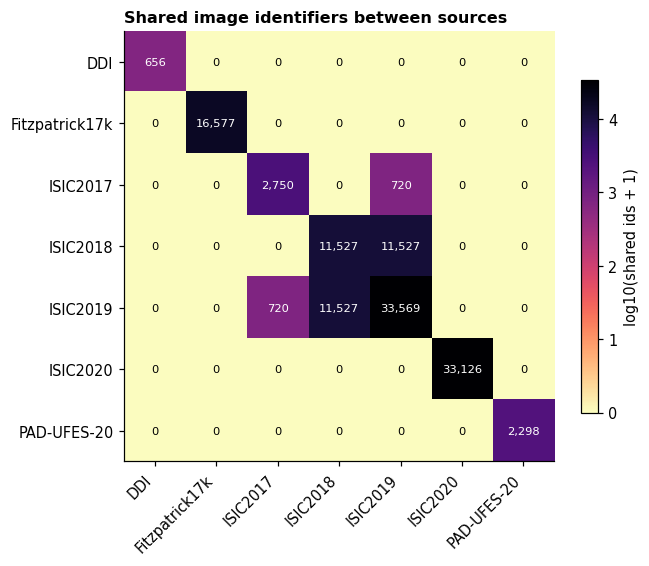

In [7]:
raw_counts = df_raw["source"].value_counts().to_dict()
uniq_counts = df_u["source"].value_counts().to_dict()
prov = pd.DataFrame([
    {"release": "ISIC 2017", "key": "ISIC2017", "role": "development",
     "labels": "challenge ground truth (train 2,000 / validation 150 / test 600)",
     "source": "ISIC challenge archive, 2017 Part 3"},
    {"release": "ISIC 2018 Task 3", "key": "ISIC2018", "role": "development",
     "labels": "train 10,015 and test 1,512 with dx_type; contained in ISIC 2019",
     "source": "ISIC challenge archive, 2018 Task 3"},
    {"release": "ISIC 2019", "key": "ISIC2019", "role": "development",
     "labels": "train 25,331 and test 8,238, both with ground truth",
     "source": "ISIC challenge archive, 2019"},
    {"release": "ISIC 2020", "key": "ISIC2020", "role": "development",
     "labels": "train 33,126; test excluded (ground truth not public)",
     "source": "ISIC challenge archive, 2020"},
    {"release": "Fitzpatrick17k", "key": "Fitzpatrick17k", "role": "external (sensitivity)",
     "labels": "atlas labels and Fitzpatrick type; not biopsy-confirmed",
     "source": "Groh et al. 2021"},
    {"release": "DDI", "key": "DDI", "role": "external (primary)",
     "labels": "biopsy-proven diagnoses and Fitzpatrick group",
     "source": "Daneshjou et al. 2022"},
    {"release": "PAD-UFES-20", "key": "PAD-UFES-20", "role": "external (consistency)",
     "labels": "biopsy flag and Fitzpatrick type",
     "source": "Pacheco et al. 2020"},
])
prov["records_downloaded"] = prov["key"].map(raw_counts).fillna(0).astype(int)
prov["unique_after_dedup"] = prov["key"].map(uniq_counts).fillna(0).astype(int)
prov = prov.drop(columns=["key"])
prov.to_csv(OUT_DIR / "data_provenance.csv", index=False)
overlap.to_csv(OUT_DIR / "release_overlap.csv")
plots.fig_overlap(overlap, OUT_DIR / "figures")

print(f"records downloaded : {prov['records_downloaded'].sum():,}")
print(f"distinct images    : {df_u['image_id'].nunique():,}")
prov

## 5. Eligibility and the histopathology-confirmed cohort

Criteria, applied in order:

1. One row per image within each release.
2. A diagnosis that resolves to malignant (melanoma, basal cell carcinoma, squamous cell carcinoma) or benign (naevus, benign keratosis, dermatofibroma, vascular lesion, actinic keratosis). Actinic keratosis is premalignant and is counted as benign. Unknown and other labels are excluded.
3. Histopathological confirmation. For ISIC 2017, 2019 and 2020 this comes from the ISIC Archive; for ISIC 2018 from the HAM10000 `dx_type` field; for PAD-UFES-20 from its biopsy field; every DDI lesion was biopsied.

Arm A applies all three criteria and is the cohort for the primary analysis. Arm B omits the third and is used only for Fitzpatrick17k, whose labels are not biopsy-confirmed.

In [8]:
cohort_histo, log_histo = cohort.build_cohort(df_u, cfg, require_histo=True)
cohort_full, log_full = cohort.build_cohort(df_u, cfg, require_histo=False)
display(log_histo)

by_release = (cohort_histo.groupby(["role", "source"])
              .agg(n=("image_id", "size"), malignant=("label_malignant", "sum"),
                   prevalence=("label_malignant", "mean"))
              .reset_index().round({"prevalence": 3}))
by_release

,step,n_before,n_removed,n_after,note
0,0. all records loaded,NaN,NaN,88256,raw union of releases
1,1. drop exact duplicate image_id within source,88256.0,0.0,88256,same file listed twice in one release
2,2. resolvable binary label,88256.0,29217.0,59039,drops UNK / OTHER classes that cannot be score...
3,3. histopathology-confirmed only,59039.0,34169.0,24870,primary analysis restriction; see verification...


,role,source,n,malignant,prevalence
0,development,ISIC2017,1649,373.0,0.226
1,development,ISIC2019,19556,9454.0,0.483
2,development,ISIC2020,1667,584.0,0.350
3,external_test,DDI,656,171.0,0.261
4,external_test,PAD-UFES-20,1342,1089.0,0.811


In [9]:
# Attrition by release
loss = pd.DataFrame([{
    "source": s, "images": len(g),
    "binary_label": int(g["label_malignant"].notna().sum()),
    "histopathology_confirmed": int(((g["confirm_histo"] == 1) & g["label_malignant"].notna()).sum()),
} for s, g in df_u.groupby("source")])
loss["excluded_label"] = loss["images"] - loss["binary_label"]
loss["excluded_not_confirmed"] = loss["binary_label"] - loss["histopathology_confirmed"]
loss.to_csv(OUT_DIR / "attrition_by_release.csv", index=False)
loss.sort_values("images", ascending=False)

,source,images,binary_label,histopathology_confirmed,excluded_label,excluded_not_confirmed
3,ISIC2019,33569,31522,19556,2047,11966
4,ISIC2020,33126,5956,1667,27170,4289
1,Fitzpatrick17k,16577,16577,0,0,16577
5,PAD-UFES-20,2298,2298,1342,0,956
2,ISIC2017,2030,2030,1649,0,381
0,DDI,656,656,656,0,0


## 6. Verification and grouping

Whether a lesion was biopsied depends on its diagnosis in ISIC 2020, HAM10000 and PAD-UFES-20, so restricting to confirmed lesions raises the proportion malignant. The grouping audit shows which identifier is available in each release; it determines the unit of the development split in notebook 02 (lesion, then patient, then image).

Histopathology confirmation rate by outcome (%):


class,source,benign,malignant,verification_gap_pp,bias_risk
0,DDI,100.0,100.0,0.0,none detected
1,Fitzpatrick17k,0.0,0.0,0.0,none detected
2,ISIC2017,77.0,100.0,23.0,HIGH
3,ISIC2019,49.1,86.4,37.3,HIGH
4,ISIC2020,20.2,100.0,79.8,SEVERE
5,PAD-UFES-20,20.9,100.0,79.1,SEVERE


Proportion malignant before and after the histopathology restriction:


,source,n_all,prevalence_all,n_histo_confirmed,prevalence_histo_only,prevalence_inflation_x
3,ISIC2019,31522,0.3471,19556,0.4834,1.39
1,Fitzpatrick17k,16577,0.1365,0,NaN,NaN
4,ISIC2020,5956,0.0981,1667,0.3503,3.57
5,PAD-UFES-20,2298,0.4739,1342,0.8115,1.71
2,ISIC2017,2030,0.1837,1649,0.2262,1.23
0,DDI,656,0.2607,656,0.2607,1.00


Image modality by role:


,role,modality,n,sources
0,development,dermoscopic,68725,"ISIC2017, ISIC2019, ISIC2020"
1,external_test,clinical,19531,"DDI, Fitzpatrick17k, PAD-UFES-20"


Grouping structure:


,source,images,lesion_id_present_%,unique_lesions,images_per_lesion,patient_id_present_%,unique_patients,images_per_patient,required_split_unit
3,ISIC2019,33569,73.8,13070.0,2.57,0.0,NaN,NaN,lesion
4,ISIC2020,33126,0.0,NaN,NaN,100.0,2056.0,16.11,patient
1,Fitzpatrick17k,16577,0.0,NaN,NaN,0.0,NaN,NaN,image
5,PAD-UFES-20,2298,100.0,1641.0,1.40,100.0,1373.0,1.67,patient
2,ISIC2017,2030,0.0,NaN,NaN,0.0,NaN,NaN,image
0,DDI,656,0.0,NaN,NaN,0.0,NaN,NaN,image


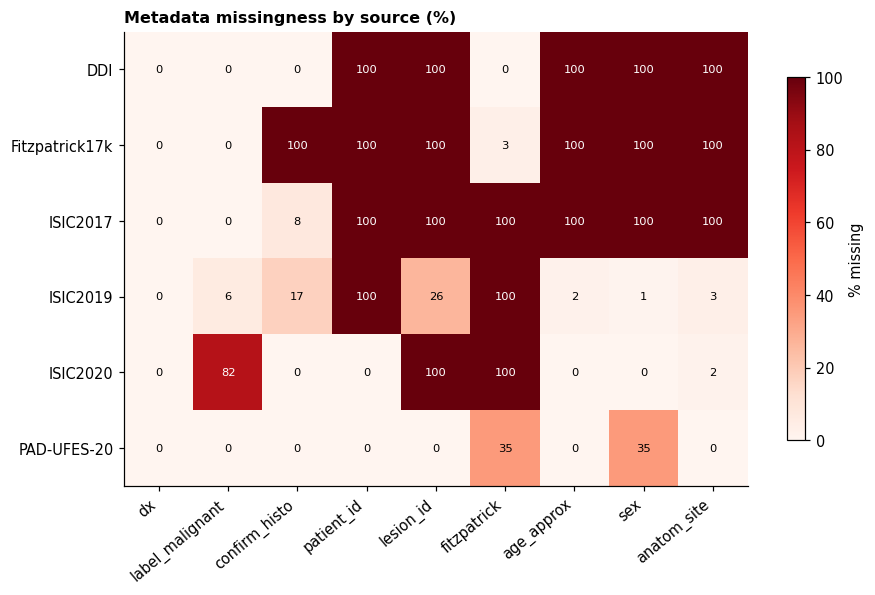

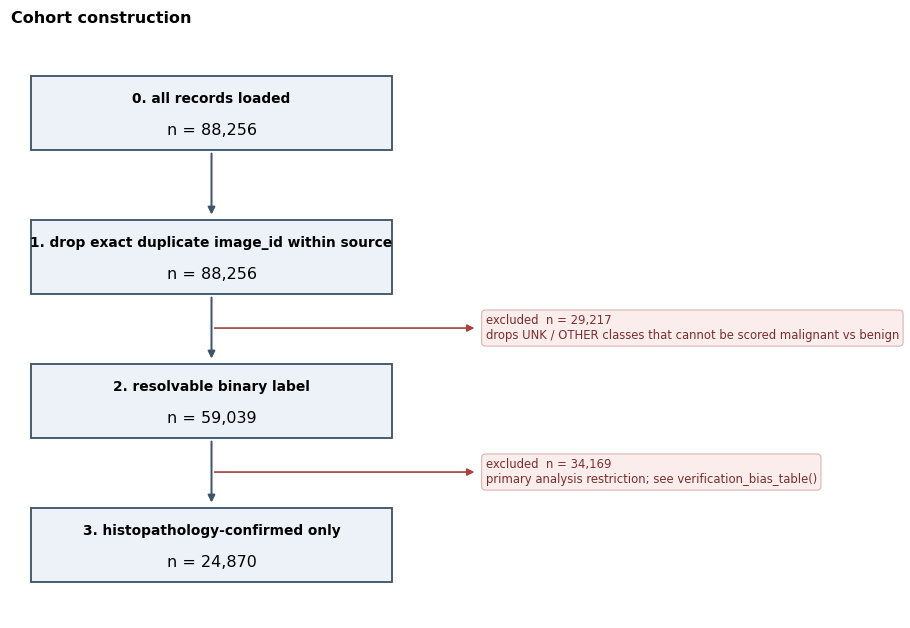

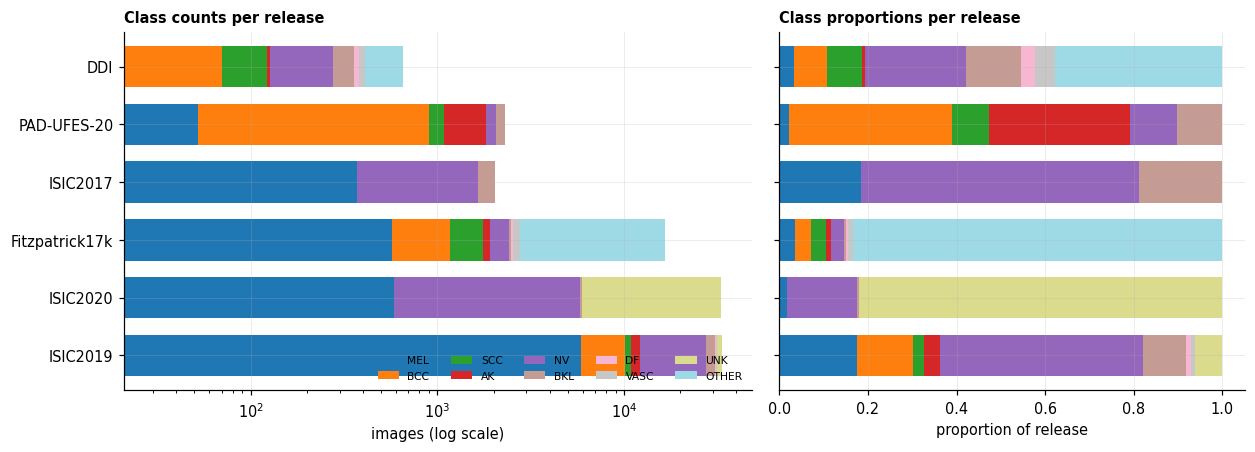

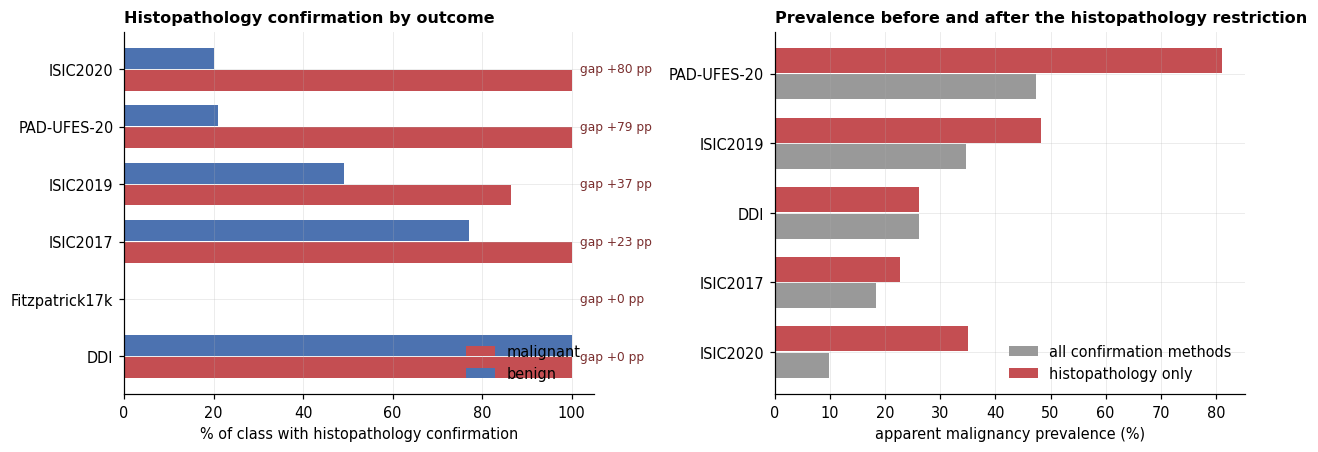

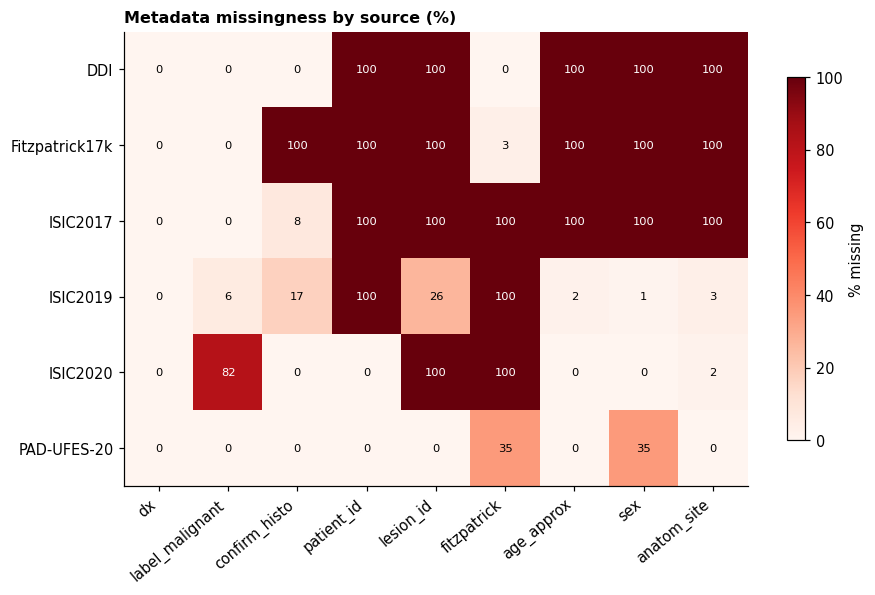

In [10]:
vb = cohort.verification_bias_table(df_u)
ps = cohort.prevalence_shift(df_u)
ga = dedup.grouping_audit(df_u)
print("Histopathology confirmation rate by outcome (%):"); display(vb)
print("Proportion malignant before and after the histopathology restriction:"); display(ps)
print("Image modality by role:"); display(cohort.modality_confound_table(df_u))
print("Grouping structure:"); display(ga)

vb.to_csv(OUT_DIR / "verification_bias.csv", index=False)
ps.to_csv(OUT_DIR / "prevalence_shift.csv", index=False)
ga.to_csv(OUT_DIR / "grouping_audit.csv", index=False)
plots.fig_attrition(log_histo, OUT_DIR / "figures")
plots.fig_class_by_source(df_u, OUT_DIR / "figures")
plots.fig_verification_bias(vb, ps, OUT_DIR / "figures")
plots.fig_missingness(df_u, OUT_DIR / "figures")

## 7. Restriction of DDI to the study outcome

DDI marks a lesion as malignant for any malignant diagnosis. Melanoma, basal cell carcinoma and squamous cell carcinoma (including in situ disease and keratoacanthoma) are kept. Lesions with any other malignant diagnosis are excluded rather than relabelled benign, because they are neither cases nor controls for this outcome.

In [11]:
ddi_mal = df_u[(df_u["source"] == "DDI") & (df_u["label_malignant"] == 1)]
print(f"DDI malignant lesions (any diagnosis): {len(ddi_mal)}")
display(pd.crosstab(ddi_mal["dx_raw"], ddi_mal["fst_group"], margins=True, margins_name="total"))

DDI malignant lesions (any diagnosis): 171


fst_group,I-II,III-IV,V-VI,total
dx_raw,,,,
atypical-spindle-cell-nevus-of-reed,0,0,1,1
basal-cell-carcinoma,7,34,0,41
basal-cell-carcinoma-nodular,6,0,0,6
basal-cell-carcinoma-superficial,1,1,0,2
blastic-plasmacytoid-dendritic-cell-neoplasm,0,1,0,1
kaposi-sarcoma,3,1,2,6
leukemia-cutis,0,1,0,1
melanoma,2,4,1,7
melanoma-acral-lentiginous,4,0,3,7


Kept:
    basal-cell-carcinoma
    basal-cell-carcinoma-nodular
    basal-cell-carcinoma-superficial
    melanoma
    melanoma-acral-lentiginous
    melanoma-in-situ
    nodular-melanoma-(nm)
    squamous-cell-carcinoma
    squamous-cell-carcinoma-in-situ
    squamous-cell-carcinoma-keratoacanthoma

Excluded:
    atypical-spindle-cell-nevus-of-reed
    blastic-plasmacytoid-dendritic-cell-neoplasm
    kaposi-sarcoma
    leukemia-cutis
    metastatic-carcinoma
    mycosis-fungoides
    sebaceous-carcinoma
    subcutaneous-t-cell-lymphoma

DDI lesions excluded: 48


,role,source,modality,n,malignant,benign,prevalence,has_fitzpatrick_%,median_age,female_%
0,development,ISIC2019,dermoscopic,19556,9454,10102,0.4834,0.0,60.0,46.1
1,development,ISIC2020,dermoscopic,1667,584,1083,0.3503,0.0,55.0,41.6
2,development,ISIC2017,dermoscopic,1649,373,1276,0.2262,0.0,NaN,NaN
3,external_test,PAD-UFES-20,clinical,1342,1089,253,0.8115,100.0,64.0,50.1
4,external_test,DDI,clinical,608,123,485,0.2023,100.0,NaN,NaN


,source,n,role,fitz_labelled_%,I-II_n,I-II_mal,III-IV_n,III-IV_mal,V-VI_n,V-VI_mal
0,ISIC2019,33569,development,0.0,0,0,0,0,0,0
1,ISIC2020,33126,development,0.0,0,0,0,0,0,0
2,Fitzpatrick17k,16577,external_test,96.6,7755,1195,6089,757,2168,208
3,PAD-UFES-20,2298,external_test,65.0,1029,783,454,301,11,5
4,ISIC2017,2030,development,0.0,0,0,0,0,0,0
5,DDI,608,external_test,100.0,201,42,232,65,175,16


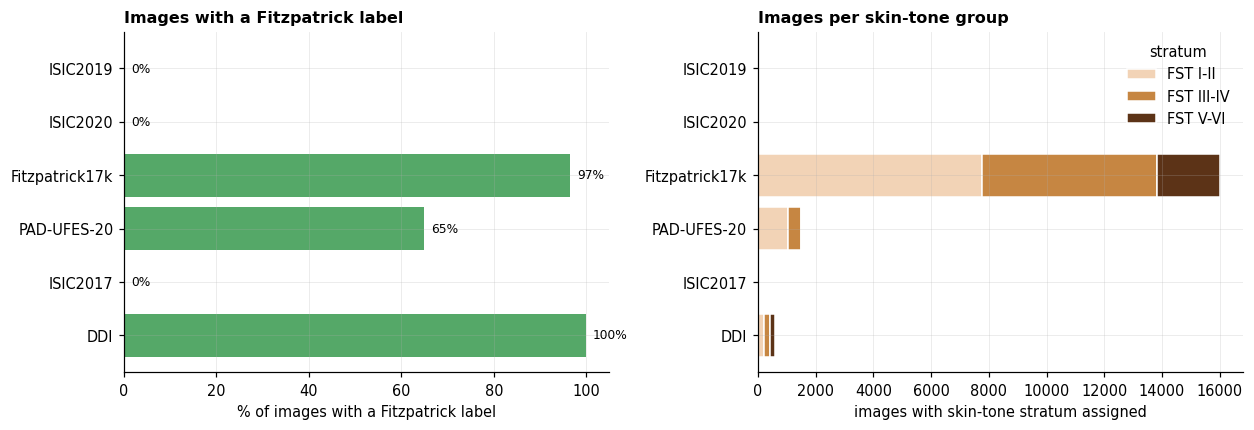

In [12]:
ENDPOINT_PATTERN = r"melanoma|basal|squamous"

is_ddi_mal = (df_u["source"] == "DDI") & (df_u["label_malignant"] == 1)
in_scope = df_u["dx_raw"].astype(str).str.lower().str.contains(ENDPOINT_PATTERN, regex=True)
drop_mask = is_ddi_mal & ~in_scope

print("Kept:")
for d in sorted(df_u.loc[is_ddi_mal & in_scope, "dx_raw"].astype(str).unique()):
    print("   ", d)
print("\nExcluded:")
for d in sorted(df_u.loc[drop_mask, "dx_raw"].astype(str).unique()):
    print("   ", d)
print(f"\nDDI lesions excluded: {int(drop_mask.sum())}")

df_ep = df_u[~drop_mask].copy()
cohort_histo_ep, log_histo_ep = cohort.build_cohort(df_ep, cfg, require_histo=True)
cohort_full_ep, log_full_ep = cohort.build_cohort(df_ep, cfg, require_histo=False)
tc_ep = cohort.tone_coverage(df_ep)
plots.fig_tone_coverage(tc_ep, OUT_DIR / "figures")
display(cohort.cohort_summary(cohort_histo_ep))
display(tc_ep)

## 8. Malignant lesions available by skin tone

Counted before any model was trained, to decide which skin-tone strata can support calibration estimates. DDI reports Fitzpatrick type in three groups, so type IV cannot be separated from type III in DDI.

In [13]:
ext = df_ep[df_ep["role"] == "external_test"]
bx_mal = ext[(ext["confirm_histo"] == 1) & (ext["label_malignant"] == 1)]

rows = []
for src, g in bx_mal.groupby("source"):
    if src == "PAD-UFES-20":
        for t in range(1, 7):
            rows.append({"source": src, "fitzpatrick": f"type {t}", "malignant": int((g["fitzpatrick"] == t).sum())})
        rows.append({"source": src, "fitzpatrick": "not recorded", "malignant": int(g["fitzpatrick"].isna().sum())})
    else:
        for grp in ["I-II", "III-IV", "V-VI"]:
            rows.append({"source": src, "fitzpatrick": f"group {grp}", "malignant": int((g["fst_group"] == grp).sum())})
counts = pd.DataFrame(rows)

pad_bx, ddi_bx = bx_mal[bx_mal["source"] == "PAD-UFES-20"], bx_mal[bx_mal["source"] == "DDI"]
darker = pd.Series({
    "PAD-UFES-20, types IV-VI": int((pad_bx["fitzpatrick"] >= 4).sum()),
    "PAD-UFES-20, types V-VI": int((pad_bx["fitzpatrick"] >= 5).sum()),
    "DDI, group III-IV": int((ddi_bx["fst_group"] == "III-IV").sum()),
    "DDI, group V-VI": int((ddi_bx["fst_group"] == "V-VI").sum()),
}, name="malignant")
darker["Types V-VI (PAD-UFES-20 and DDI)"] = darker["PAD-UFES-20, types V-VI"] + darker["DDI, group V-VI"]
darker["Types IV-VI (PAD-UFES-20 IV-VI and DDI V-VI)"] = darker["PAD-UFES-20, types IV-VI"] + darker["DDI, group V-VI"]

counts.to_csv(OUT_DIR / "malignant_counts_by_skin_tone.csv", index=False)
darker.to_csv(OUT_DIR / "malignant_counts_darker_skin.csv")
display(counts)
darker.to_frame()

,source,fitzpatrick,malignant
0,DDI,group I-II,42
1,DDI,group III-IV,65
2,DDI,group V-VI,16
3,PAD-UFES-20,type 1,120
4,PAD-UFES-20,type 2,663
5,PAD-UFES-20,type 3,272
6,PAD-UFES-20,type 4,29
7,PAD-UFES-20,type 5,5
8,PAD-UFES-20,type 6,0
9,PAD-UFES-20,not recorded,0


,malignant
"PAD-UFES-20, types IV-VI",34
"PAD-UFES-20, types V-VI",5
"DDI, group III-IV",65
"DDI, group V-VI",16
Types V-VI (PAD-UFES-20 and DDI),21
Types IV-VI (PAD-UFES-20 IV-VI and DDI V-VI),50


,source,fst_group,n,malignant,benign,prevalence,AUC_95CI_halfwidth,OE_95CI_fold_width,calib_slope_SE,calib_bin_95CI_halfwidth,netbenefit_SE_at_pt0.1,meets_Riley_min_100,reportable_calibration,verdict
0,Fitzpatrick17k,I-II,7755,1195,6560,0.1541,0.0141,1.11,0.024,0.025,0.00386,True,True,adequate
1,Fitzpatrick17k,III-IV,6089,757,5332,0.1243,0.0176,1.14,0.030,0.026,0.00398,True,True,adequate
2,Fitzpatrick17k,V-VI,2168,208,1960,0.0959,0.0334,1.29,0.057,0.040,0.00595,True,True,adequate
3,PAD-UFES-20,I-II,1029,783,246,0.7609,0.0234,1.07,0.029,0.081,0.01492,True,True,adequate
4,PAD-UFES-20,NaN,804,0,804,0.0000,NaN,NaN,NaN,0.033,NaN,False,False,NOT EVALUABLE - report counts only
5,Fitzpatrick17k,NaN,565,103,462,0.1823,0.0482,1.42,0.080,0.099,0.01532,True,True,adequate
6,PAD-UFES-20,III-IV,454,301,153,0.6630,0.0342,1.14,0.047,0.133,0.02331,True,True,adequate
7,DDI,III-IV,232,65,167,0.2802,0.0622,1.51,0.101,0.170,0.02808,False,True,"underpowered - report interval estimates, no h..."
8,DDI,I-II,201,42,159,0.2090,0.0761,1.71,0.126,0.168,0.02711,False,True,"underpowered - report interval estimates, no h..."
9,DDI,V-VI,175,16,159,0.0914,0.1206,2.54,0.204,0.155,0.02050,False,False,descriptive only - no calibration curve


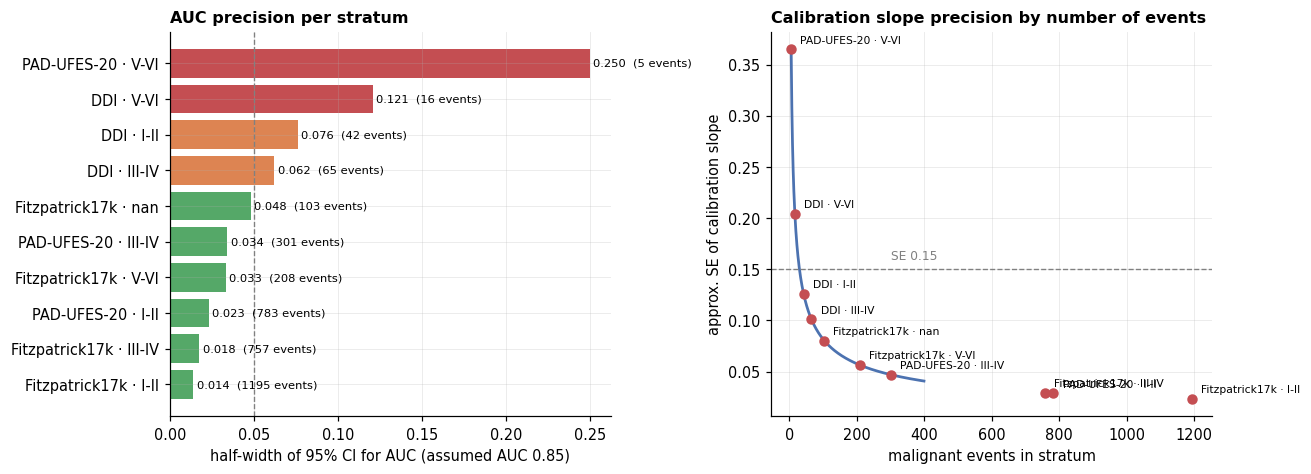

In [14]:
# Approximate precision per stratum (dermcal.power)
ext_ep = cohort_full_ep[cohort_full_ep["role"] == "external_test"].copy()
feas_ep = power.feasibility_table(ext_ep, group_cols=("source", "fst_group"),
                                  assumed_auc=0.85, min_events=cfg.min_events_per_subgroup)
feas_ep.to_csv(OUT_DIR / "feasibility_endpoint.csv", index=False)
plots.fig_power(feas_ep, OUT_DIR / "figures")
feas_ep

## 9. Save cohorts

In [15]:
t1 = pd.concat([cohort.cohort_summary(cohort_histo_ep),
                cohort.cohort_summary(cohort_full_ep[cohort_full_ep["source"] == "Fitzpatrick17k"])],
               ignore_index=True)

summary = {
    "records_downloaded": int(prov["records_downloaded"].sum()),
    "distinct_images": int(df_u["image_id"].nunique()),
    "with_binary_label": int(len(cohort_full)),
    "histopathology_confirmed": int(len(cohort_histo)),
    "histopathology_confirmed_development": int((cohort_histo["role"] == "development").sum()),
    "histopathology_confirmed_external": int((cohort_histo["role"] == "external_test").sum()),
    "ddi_excluded_other_malignancy": int(drop_mask.sum()),
    "images_with_fitzpatrick_label": int(df_u["fst_group"].notna().sum()),
}

cohort_histo_ep.to_csv(OUT_DIR / "cohort_arm_a_endpoint.csv", index=False)
cohort_full_ep.to_csv(OUT_DIR / "cohort_arm_b_endpoint.csv", index=False)
log_histo_ep.to_csv(OUT_DIR / "attrition_arm_a_endpoint.csv", index=False)
tc_ep.to_csv(OUT_DIR / "tone_coverage_endpoint.csv", index=False)
t1.to_csv(OUT_DIR / "table1_cohort_summary.csv", index=False)
(OUT_DIR / "cohort_summary.json").write_text(json.dumps(summary, indent=2))

display(pd.Series(summary, name="n").to_frame())
sorted(p.name for p in OUT_DIR.glob("*.*"))

,n
records_downloaded,100503
distinct_images,88256
with_binary_label,59039
histopathology_confirmed,24870
histopathology_confirmed_development,22872
histopathology_confirmed_external,1998
ddi_excluded_other_malignancy,48
images_with_fitzpatrick_label,18162


['attrition_arm_a_endpoint.csv',
 'attrition_by_release.csv',
 'cohort_arm_a_endpoint.csv',
 'cohort_arm_b_endpoint.csv',
 'cohort_summary.json',
 'data_provenance.csv',
 'feasibility_endpoint.csv',
 'grouping_audit.csv',
 'malignant_counts_by_skin_tone.csv',
 'malignant_counts_darker_skin.csv',
 'prevalence_shift.csv',
 'release_overlap.csv',
 'run_config.json',
 'table1_cohort_summary.csv',
 'tone_coverage_endpoint.csv',
 'verification_bias.csv']